# 📌 Submission Guidelines

### ✅ File Naming Rule  
Submit your notebook with the following format:

`StudentID_YourFullName_LABXX.ipynb`

or

`StudentID_YourFullName_LABXX.html`

**Examples (Correct):**
- `21113456_NguyenVanA_LAB01.ipynb`
- `19122233_TranThiB_LAB02.ipynb`

**Examples (Wrong → 0 points):**
- `Lab01.ipynb`
- `YourName.ipynb`
- `20123456.ipynb`
- `Lab01.pdf`

---

### 📌 Grading Policy

- ❌ Wrong filename format, missing submission, or plagiarism (code identical to others) → 0 points

- ⚠️ Submitting a file without results, incomplete work, or only the assignment description → Maximum 4 points

- ✅ Correct filename + Completed results → Graded normally based on assignment quality (accuracy, clarity, and originality)  
### Note:
- AI assistance is allowed, but you must write the code yourself. All submissions will be checked for originality.

---



## LEARNING OBJECTIVES

### 🧠 Conceptual Understanding

- Understand how **GloVe** is based on **co-occurrence statistics**
- Understand the differences between:
  - **One-hot encoding**
  - **Word2Vec (Skip-gram / CBOW)**
  - **GloVe**
- Understand the meaning of a **co-occurrence matrix**
- Understand why **co-occurrence probability ratios** capture semantic meaning

### 💻 Practical Skills

- Build a **co-occurrence matrix**
- Implement a **simplified version of GloVe**
- Train word embeddings on a **small corpus**
- Analyze embeddings using **cosine similarity**




## SHORT THEORY

###Limitation of One-hot Encoding

- Vectors are **very large and sparse**
- Do **not capture semantic meaning**
- Cannot measure **similarity between words**


### Word Embedding

- Words are represented as **dense vectors**:
 king ≈ queen → vector gần nhau

### Co-occurrence Matrix

- Counts how often words appear together within a context window.

**Example**

Sentence: "I love NLP"

Window = 1

→ Co-occurrence matrix:

|     | I | love | NLP |
|-----|---|------|-----|
| I   | 0 | 1    | 0   |
| love| 1 | 0    | 1   |
| NLP | 0 | 1    | 0   |


### Core Idea of GloVe

> 💡 GloVe does not only count co-occurrences — it leverages **ratios of co-occurrence probabilities**

Example:

$$
\frac{P(\text{ice} \mid \text{solid})}{P(\text{steam} \mid \text{solid})}
$$

→ Helps distinguish semantic meaning.


### Loss Function (Simplified)

$$
J = \sum_{i,j} f(X_{ij}) \left( w_i^T w_j + b_i + b_j - \log X_{ij} \right)^2
$$

Where:

- $X_{ij}$: co-occurrence count between word $i$ and $j$  
- $w_i$: word vector  
- $b_i$: bias term  
- $f(x)$: weighting function  

> 💡 The model learns embeddings such that dot products approximate **log co-occurrence counts**.

### GloVe vs Word2Vec

| Aspect | GloVe | Skip-gram (Word2Vec) |
|--------|------|----------------------|
| Data | Global statistics | Local context |
| Input | Co-occurrence matrix | Context window |
| Training | Batch | Online |


> 🎯 Summary:
>
> - **Word2Vec** learns from predicting context  
> - **GloVe** learns from global co-occurrence structure

paper: [GloVe: global vectors for word representation](https://aclanthology.org/D14-1162.pdf)

#Code Sample

## Dataset

In [1]:
corpus = [
    "I love natural language processing",
    "I love deep learning",
    "natural language processing is fun",
    "deep learning is powerful",
    "machine learning is interesting",
    "I enjoy studying machine learning",
    "deep neural networks are powerful",
    "natural language processing is important",
    "I love studying artificial intelligence",
    "artificial intelligence is the future",
    "deep learning models are effective",
    "machine learning models are useful",
    "natural language processing helps understanding text",
    "deep learning is used in computer vision",
    "I enjoy learning about neural networks",
    "AI is transforming the world",
    "data science and machine learning are related",
    "neural networks learn representations",
    "deep learning requires large data",
    "natural language processing is a part of AI"
]

tokens = [sentence.lower().split() for sentence in corpus]


vocab = set()
for sentence in tokens:
    vocab.update(sentence)

vocab = list(vocab)

word_to_idx = {w:i for i,w in enumerate(vocab)}
idx_to_word = {i:w for w,i in word_to_idx.items()}

vocab_size = len(vocab)

## BUILD CO-OCCURRENCE MATRIX

### Context window

In [2]:
window_size = 2

### Build matrix

In [3]:
import numpy as np

co_matrix = np.zeros((vocab_size, vocab_size))

for sentence in tokens:
    for i, word in enumerate(sentence):
        word_idx = word_to_idx[word]

        for j in range(-window_size, window_size+1):
            if j == 0:
                continue

            if 0 <= i+j < len(sentence):
                context_word = sentence[i+j]
                context_idx = word_to_idx[context_word]

                co_matrix[word_idx][context_idx] += 1

In [4]:
co_matrix

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 1., ..., 0., 1., 1.],
       [0., 1., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.]], shape=(47, 47))

### Distance weighting (optional)

In [5]:
distance = abs(j)
co_matrix[word_idx][context_idx] += 1 / distance

## IMPLEMENT GLOVE (SIMPLIFIED)

In [6]:
import torch
import torch.nn as nn
import torch.optim as optim

In [7]:
class GloVe(nn.Module):

    def __init__(self, vocab_size, embed_dim):
        super().__init__()

        self.wi = nn.Embedding(vocab_size, embed_dim)
        self.wj = nn.Embedding(vocab_size, embed_dim)

        self.bi = nn.Embedding(vocab_size, 1)
        self.bj = nn.Embedding(vocab_size, 1)

    def forward(self, i, j):

        wi = self.wi(i)
        wj = self.wj(j)

        bi = self.bi(i).squeeze()
        bj = self.bj(j).squeeze()

        dot = (wi * wj).sum(dim=1)

        return dot + bi + bj

In [8]:
def weighting(x, x_max=100, alpha=0.75):
    return (x / x_max) ** alpha if x < x_max else 1

## TRAINING

In [9]:
pairs = []

for i in range(vocab_size):
    for j in range(vocab_size):
        if co_matrix[i][j] > 0:
            pairs.append((i, j, co_matrix[i][j]))

In [10]:
model = GloVe(vocab_size, embed_dim=10)
optimizer = optim.Adam(model.parameters(), lr=0.01)

epochs = 200

for epoch in range(epochs):
    total_loss = 0

    for i, j, x in pairs:

        i = torch.tensor([i])
        j = torch.tensor([j])
        x = torch.tensor([x], dtype=torch.float)

        pred = model(i, j)

        log_x = torch.log(x)

        weight = weighting(x.item())

        loss = weight * (pred - log_x) ** 2

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    if epoch % 20 == 0:
        print("Epoch:", epoch, "Loss:", total_loss)

Epoch: 0 Loss: 99.97926058923635
Epoch: 20 Loss: 2.5857395805461465
Epoch: 40 Loss: 1.4659124018018872
Epoch: 60 Loss: 0.8593195247011733
Epoch: 80 Loss: 0.6930827353200186
Epoch: 100 Loss: 0.4260490558450556
Epoch: 120 Loss: 0.33774905340025896
Epoch: 140 Loss: 0.6947621604458636
Epoch: 160 Loss: 0.45849869889835404
Epoch: 180 Loss: 0.4143413324362948


## ANALYSIS / VISUALIZATION

### Cosine similarity

In [11]:
from sklearn.metrics.pairwise import cosine_similarity

embeddings = model.wi.weight.data

def most_similar(word, top_k=5):
    idx = word_to_idx[word]
    vec = embeddings[idx].unsqueeze(0)

    sims = cosine_similarity(vec, embeddings)[0]

    top_idx = sims.argsort()[-top_k:]

    for i in top_idx:
        print(idx_to_word[i])

In [12]:
most_similar("learning")

natural
the
processing
language
learning


### PCA visualization

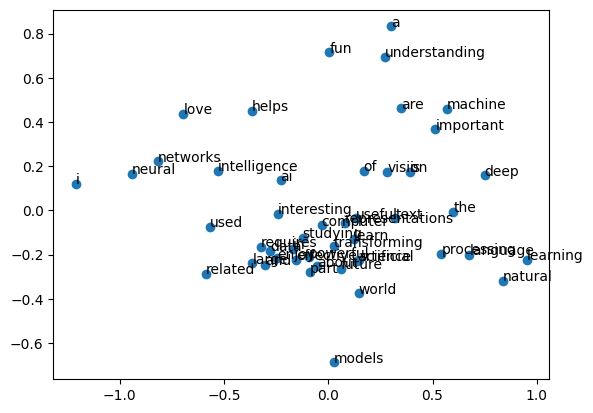

In [13]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
reduced = pca.fit_transform(embeddings)

plt.scatter(reduced[:,0], reduced[:,1])

for i, word in enumerate(vocab):
    plt.annotate(word, (reduced[i,0], reduced[i,1]))

plt.show()

 # Homewwork

## 💬 Discussion Questions

1️⃣ Why is co-occurrence important?

2️⃣ Why is a weighting function needed?

3️⃣ How do rare words affect the model?

4️⃣ Why is GloVe considered a “global” model?

5️⃣ When does GloVe perform better than Word2Vec?

1️⃣ Why is co-occurrence important?\
Co-occurrence is the foundation of "meaning" in GloVe. Instead of just looking at which words appear near each other, GloVe looks at the ratio of co-occurrence probabilities.
The creators found that the raw probability of a word $k$ appearing near "Ice" vs. "Steam" isn't as informative as the ratio:
- If $k = \text{"solid"}$, it is much more likely to appear with "Ice" than "Steam." The ratio is high.
- If $k = \text{"gas"}$, it is much more likely to appear with "Steam." The ratio is low.
- If $k = \text{"water"}$ or $\text{"fashion"}$, it is either equally likely or equally unlikely for both. The ratio is close to $1$.
By training on these ratios, the model learns the fine-grained nuances that distinguish related concepts.

2️⃣ Why is a weighting function needed?\
In a massive corpus, co-occurrence counts ($X_{ij}$) vary wildly. A weighting function $f(X_{ij})$ is used for two main reasons:
- Preventing "The" from dominating: Extremely frequent words (like "the", "is", "a") have massive co-occurrence counts. Without weighting, the model would spend all its energy trying to "fix" the vectors for these common words while ignoring others.
- Noise reduction: Very low co-occurrence counts are often "noisy" or coincidental. The weighting function ensures these don't carry too much weight in the loss function, effectively "smoothing" the learning process.

3️⃣ How do rare words affect the model?\
Rare words are a challenge for any model. In GloVe:
- Because GloVe relies on aggregated counts, a rare word might only have a few entries in the global matrix.
- If the co-occurrence count is $1$ or $2$, the statistical "signal" is weak.
- However, GloVe handles this better than simple matrix factorization because the weighting function assigned to these rare pairs is low, meaning the model doesn't "over-fit" to a rare, potentially random occurrence.

4️⃣ Why is GloVe considered a “global” model?\
Word2Vec is a "local" model because it scans the corpus sentence by sentence. It only "sees" what is inside its current window at any given moment.\
GloVe is "global" because it first builds a Global Co-occurrence Matrix of the entire corpus. Once that matrix is built, the model trains on the entries of that matrix. It essentially has a "bird's-eye view" of how every word in the entire library relates to every other word before it even begins the optimization process.

5️⃣ When does GloVe perform better than Word2Vec?
While both produce high-quality embeddings, GloVe often has the edge in specific scenarios:
- Analogy Tasks: GloVe was specifically designed to excel at linear relationships (like King - Man + Woman = Queen). It often outperforms Word2Vec on semantic analogy benchmarks.
- Smaller Datasets: Because it uses global statistics, it can sometimes extract more "meaning" from a smaller corpus where Word2Vec might need more passes to see enough local contexts.
- Training Speed (Post-Matrix): Once the co-occurrence matrix is built (which is the slow part), training the actual vectors is often faster than Word2Vec because the model is iterating over the unique word pairs in the matrix rather than every single word in the original text.

## 🧪 Experiments & Exercises



In [6]:
from datasets import load_dataset

dataset = load_dataset("VTSNLP/vietnamese_curated_dataset",split="train",streaming = True)
print(dataset)

Resolving data files:   0%|          | 0/132 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/132 [00:00<?, ?it/s]

IterableDataset({
    features: ['text', 'id', 'domain'],
    n_shards: 132
})


## 🧪 LAB PIPELINE: GloVe Implementation

---

### PART 1 — DATA PREPROCESSING

#### ✅ Requirements

- Extract text:

```python
texts = [item['text'] for item in dataset]
```

Clean the data:
- Convert to lowercase
- Remove special characters
- Remove numbers

Tokenization:
```python
from underthesea import word_tokenize
```

Questions
- What kinds of noise exist in web data?
- What makes Vietnamese tokenization challenging?

### PART 2 — VOCABULARY
####✅ Requirements
Limit vocabulary size:
```python
max_vocab = 10000
Remove low-frequency words:
min_freq = 5
```
Questions

How does a larger vocabulary affect:
- Memory usage?
- Training time?

### PART 3 — CO-OCCURRENCE MATRIX
#### ✅ Requirements
Build the co-occurrence matrix with:
- window_size = 2 / 5
- Apply distance weighting:
  - weight = 1 / distance

Analysis
- How does a larger window size change the matrix?
- Why is weighting by distance important?

### PART 4 — IMPLEMENT GLOVE
#### ✅ Requirements

Implement all components:
- Word vectors
- Context vectors
- Bias terms
- Weighting function

🧪 Experiments
Change:
- embedding_dim = 50 / 100

### PART 5 — TRAINING
#### ✅ Requirements
- Train for at least 50–100 epochs
- Log the training loss

🎯 Analysis
- Does the loss decrease over time?
- Does it plateau?

### PART 6 — WORD SIMILARITY (IMPORTANT)
#### ✅ Requirements

Implement and test:
- most_similar("học")
- most_similar("công_nghệ")
- most_similar("việt_nam")

🎯 Analysis
- Do the results show semantic meaning?
- Are there any noisy or irrelevant words?

### PART 7 — VISUALIZATION
#### ✅ Requirements
- Use PCA or t-SNE
- Visualize ~100 frequent words

🎯 Questions
- Do similar words form clusters?
- Are different topics well separated?

### PART 8 — COMPARISON (IMPORTANT)
Students write a report comparing:
- Metric	GloVe	Skip-gram
- Speed
- Quality
- Stability

In [2]:
import re
from underthesea import word_tokenize
import time
import psutil
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from datasets import load_dataset
from torch.utils.data import TensorDataset, DataLoader
import torch.nn.functional as F
from collections import Counter

## Part 1: Data preprocessing

In [4]:
def preprocess(example):
    text = example['text']
    #Convert to lowercase
    text = text.lower()
    #Remove speacial characters
    text = re.sub(r'[^\w\s_]', '', text)
    #Remove numbers
    text = re.sub(r'\d+', '', text)
    #Tokenize
    text = word_tokenize(text, format="text")
    return {"processed_text": text}

Áp dụng hàm processed lên dataset, tạo ra processed_dataset là bộ dữ liệu sau khi tiền xử lý

In [7]:
processed_dataset = dataset.map(preprocess)

for i, example in enumerate(processed_dataset):
    print(example['processed_text'])
    if i == 2: break

internet society hay isoc là một tổ_chức quốc_tế hoạt_động phi_lợi_nhuận phi_chính_phủ và bao_gồm các thành_viên có trình_độ chuyên_ngành tổ_chức này chú_trọng đến tiêu_chuẩn giáo_dục và các vấn_đề về chính_sách với trên tổ_chức thành_viên và thành_viên cá_nhân isoc bao_gồm những con_người cụ_thể trong cộng_đồng internet mọi chi_tiết có_thể tìm thấy tại website của isoc internet society nằm ở gần thủ_đô washington dc hoa_kỳ và geneva thụy_sĩ số hội_viên của nó bao_gồm hơn tổ_chức thành_viên và hơn cá_nhân thành_viên còn có_thể tự_lập một chi_nhánh của tổ_chức tùy theo vị_trí hoặc sở_thích hiện_nay tổ_chức có tới chi_nhánh trên toàn thế_giới nhiệm_vụ và mục_đích hoạt_động bảo_đảm cổ_vũ cho sự phát_triển mở_rộng và sử_dụng internet được thuận_lợi nhất cho mọi người trên toàn thế_giới xem thêm lịch_sử internet tham_khảo liên_kết ngoài isoc việt_nam ietf and_the internet society về internet engineering task force và isoc bài của vint cerf lassociation internationale de lutte contre_la cybe

Noise in Web Data
- Boilerplate: Non-content text like navigation menus, ads, and footers.
- Technical Artifacts: Stray HTML tags, CSS, or broken character encodings.
- Social Noise: Teencode, slang, excessive emojis, and "keyboard mash".
- Code-switching: Mixing multiple languages in a single sentence.

Vietnamese Tokenization Challenges
- Space Ambiguity: In Vietnamese, spaces separate syllables, not necessarily words (e.g., "học sinh" is one word, two syllables).
- Segmentation Ambiguity: The same sequence of syllables can mean different things depending on how you group them (e.g., "ông già" could be "old man" or "he ages").
- Compound/Reduplicated Words: Difficulty in distinguishing between standalone syllables and complex words like từ ghép or từ láy.

## Part 2: Vocabulary

Build a vocabulary

In [1]:
def get_memory_usage():
    process = psutil.Process(os.getpid())
    return process.memory_info().rss / (1024 ** 2)

In [8]:
start_time = time.perf_counter()
start_mem = get_memory_usage()

word_counts = Counter()

for i, example in enumerate(processed_dataset):
    # Lấy danh sách từ (tokens) từ chuỗi đã tokenize
    tokens = example['processed_text'].split()
    #cập nhập số lần mỗi từ xuất hiện với mỗi câu
    word_counts.update(tokens)
    # Sau khi thử nghiệm nhiều lần, ta thấy với 2000 dòng đầu tiên thì vocab
    # đã đủ 10000 từ nên ta dừng để tối ưu thời gian
    if i > 2000:
        break

max_vocab = 10000
min_freq = 5

#lọc số từ xuất hiện < 5
vocab_filtered = [word for word, count in word_counts.items() if count >= min_freq]

#sort vocab
vocab_sorted = sorted(vocab_filtered, key=lambda x: word_counts[x], reverse=True)

#Giới hạn số từ = 10000
final_vocab = vocab_sorted[:max_vocab]

# Ánh xạ word và idx và ngược lại
word_to_idx = {word: i for i, word in enumerate(final_vocab)}
idx_to_word = {i: word for i, word in enumerate(final_vocab)}

end_time = time.perf_counter()
end_mem = get_memory_usage()

Kiểm tra bộ nhớ và thời gian cho phần tạo vocab

In [9]:
print("Memory usage: ", end_mem - start_mem)
print("Time: ", end_time - start_time)

Memory usage:  33.44140625
Time:  75.2442192999988


In [10]:
vocab_size = len(final_vocab)
vocab_size

10000

1️⃣ Memory Usage
- Dictionaries ($O(V)$): Memory for word_to_idx and idx_to_word grows linearly with vocabulary size ($V$).
- Co-occurrence Matrix ($O(V^2)$): This is the biggest bottleneck. If you double $V$, the matrix size increases quadrupled (e.g., $10,000^2 \rightarrow 20,000^2$).
- Embedding Weights: The parameter matrix ($V \times \text{dimension}$) also grows linearly, requiring more RAM/VRAM.

2️⃣ Training Time
- Vocabulary Building: Minimal impact; sorting and filtering a larger list is still very fast.
- Matrix Construction: The processing time stays mostly the same (since it depends on the number of tokens in your dataset), but memory access might slow down due to cache misses with a massive matrix.
- Optimization: More parameters mean the model requires more iterations to converge and each training epoch takes longer to process all word pairs.

## Part 3: Co-occurrence matrix

Tạo ma trận Co-occurrence với window_size là 2

In [13]:
window_size = 2

co_matrix = np.zeros((vocab_size, vocab_size))

for idx, sentence in enumerate(processed_dataset):
    # Lấy danh sách từ
    tokens = sentence['processed_text'].split()
    for i, word in enumerate(tokens):
        # Kiểm tra xem từ này có trong vocab
        if word not in word_to_idx:
            continue
        word_idx = word_to_idx[word]

        for j in range(-window_size, window_size+1):
            if j == 0:
                continue

            if i + j >= 0 and i + j < len(tokens):
                context_word = tokens[i + j]

                #Kiểm tra các từ bên cạnh có trong vocab không
                if context_word in word_to_idx:
                    context_idx = word_to_idx[context_word]
                    
                    distance = abs(j)
                    co_matrix[word_idx][context_idx] += 1 / distance
            
    if idx > 2000: 
        break

In [14]:
print(co_matrix)

[[115.  442.5 441.5 ...   1.    0.    1. ]
 [442.5  47.  435.  ...   1.    0.    0. ]
 [441.5 435.   33.  ...   0.    0.    0. ]
 ...
 [  1.    1.    0.  ...   0.    0.    0. ]
 [  0.    0.    0.  ...   0.    0.    0. ]
 [  1.    0.    0.  ...   0.    0.    0. ]]


Tạo ma trận Co-occurrence với window_size là 5

In [15]:
window_size = 5

co_matrix = np.zeros((vocab_size, vocab_size))

for idx, sentence in enumerate(processed_dataset):
    # Lấy danh sách từ
    tokens = sentence['processed_text'].split()
    for i, word in enumerate(tokens):
        # Kiểm tra xem từ này có trong vocab
        if word not in word_to_idx:
            continue
        word_idx = word_to_idx[word]

        for j in range(-window_size, window_size+1):
            if j == 0:
                continue

            if i + j >= 0 and i + j < len(tokens):
                context_word = tokens[i + j]

                #Kiểm tra các từ bên cạnh có trong vocab không
                if context_word in word_to_idx:
                    context_idx = word_to_idx[context_word]
                    
                    distance = abs(j)
                    co_matrix[word_idx][context_idx] += 1 / distance
            
    if idx > 2000: 
        break

In [16]:
print(co_matrix)

[[3.62666667e+02 9.68950000e+02 8.34500000e+02 ... 1.00000000e+00
  2.50000000e-01 1.50000000e+00]
 [9.68950000e+02 3.61166667e+02 1.05045000e+03 ... 1.00000000e+00
  0.00000000e+00 2.50000000e-01]
 [8.34500000e+02 1.05045000e+03 2.52266667e+02 ... 0.00000000e+00
  0.00000000e+00 0.00000000e+00]
 ...
 [1.00000000e+00 1.00000000e+00 0.00000000e+00 ... 0.00000000e+00
  0.00000000e+00 0.00000000e+00]
 [2.50000000e-01 0.00000000e+00 0.00000000e+00 ... 0.00000000e+00
  0.00000000e+00 0.00000000e+00]
 [1.50000000e+00 2.50000000e-01 0.00000000e+00 ... 0.00000000e+00
  0.00000000e+00 0.00000000e+00]]


1️⃣ How does a larger window size change the matrix?
- Density: The matrix becomes denser with more non-zero entries because each word captures more neighbors.
- Scope: It shifts the focus from syntax (local grammar/part-of-speech) to semantics (broader topical relationships).
- Computation: It increases processing time as the inner loop runs more iterations per word.
- 
2️⃣ Why is weighting by distance important?
- Strength of Correlation: Words closer to the target usually carry more relevant meaning than those further away.
- Noise Reduction: It prevents distant, unrelated words in a long sentence from having the same influence as immediate neighbors.
- Model Quality: In algorithms like GloVe, using $1/d$ helps produce more accurate vector representations by prioritizing immediate context.

## Part 4: Implement glove

Implement Glove using Pytorch

In [17]:
class GloVe(nn.Module):

    def __init__(self, vocab_size, embed_dim):
        super().__init__()

        self.wi = nn.Embedding(vocab_size, embed_dim)
        self.wj = nn.Embedding(vocab_size, embed_dim)

        self.bi = nn.Embedding(vocab_size, 1)
        self.bj = nn.Embedding(vocab_size, 1)

    def forward(self, i, j):

        wi = self.wi(i)
        wj = self.wj(j)

        bi = self.bi(i).squeeze()
        bj = self.bj(j).squeeze()

        dot = (wi * wj).sum(dim=1)

        return dot + bi + bj

In [18]:
def weighting(x, x_max=100, alpha=0.75):
    weights = (x / x_max) ** alpha
    return torch.where(x < x_max, weights, torch.tensor(1.0, device=x.device))

## Part 5: Training

Tạo các cặp chuẩn bị cho training.
co_matrix ở đây là của window_size 5

In [19]:
pairs = []

for i in range(vocab_size):
    for j in range(vocab_size):
        if co_matrix[i][j] > 0:
            pairs.append((i, j, co_matrix[i][j]))

In [ ]:
# Chuẩn bị để chạy bằng GPU
device = torch.device("cuda")

i_tensors = torch.tensor([p[0] for p in pairs], dtype=torch.long)
j_tensors = torch.tensor([p[1] for p in pairs], dtype=torch.long)
x_tensors = torch.tensor([p[2] for p in pairs], dtype=torch.float)

batch_size = 4069 
dataset = TensorDataset(i_tensors, j_tensors, x_tensors)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

Embed_dim = 50, epochs = 100

In [22]:
glove_50 = GloVe(vocab_size, embed_dim=50).to(device)
optimizer = optim.Adam(glove_50.parameters(), lr=0.01)

epochs = 100

for epoch in range(1, epochs + 1):
    total_loss = 0

    for i_batch, j_batch, x_batch in dataloader:

        i_batch = i_batch.to(device)
        j_batch = j_batch.to(device)
        x_batch = x_batch.to(device)

        pred = glove_50(i_batch, j_batch)

        log_x = torch.log(x_batch)

        weight = weighting(x_batch)

        loss = (weight * (pred - log_x) ** 2).mean()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    if epoch % 10 == 0:
        print("Epoch:", epoch, "Loss:", total_loss)

Epoch: 10 Loss: 13.164594316855073
Epoch: 20 Loss: 8.769098216667771
Epoch: 30 Loss: 7.942517144605517
Epoch: 40 Loss: 7.740906075574458
Epoch: 50 Loss: 7.642902757972479
Epoch: 60 Loss: 7.574810489080846
Epoch: 70 Loss: 7.566758121363819
Epoch: 80 Loss: 7.550185451284051
Epoch: 90 Loss: 7.536581698805094
Epoch: 100 Loss: 7.509914637543261


Embed_dim = 100, epochs = 100

In [35]:
glove_100 = GloVe(vocab_size, embed_dim=100).to(device)
optimizer = optim.Adam(glove_100.parameters(), lr=0.01)

epochs = 100

for epoch in range(1, epochs + 1):
    total_loss = 0

    for i_batch, j_batch, x_batch in dataloader:

        i_batch = i_batch.to(device)
        j_batch = j_batch.to(device)
        x_batch = x_batch.to(device)

        pred = glove_100(i_batch, j_batch)

        log_x = torch.log(x_batch)

        weight = weighting(x_batch)

        loss = (weight * (pred - log_x) ** 2).mean()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    if epoch % 10 == 0:
        print("Epoch:", epoch, "Loss:", total_loss)

Epoch: 10 Loss: 25.140326268970966
Epoch: 20 Loss: 11.671437833458185
Epoch: 30 Loss: 8.555513614788651
Epoch: 40 Loss: 7.87145468685776
Epoch: 50 Loss: 7.636991717852652
Epoch: 60 Loss: 7.5497974418103695
Epoch: 70 Loss: 7.470941702835262
Epoch: 80 Loss: 7.490827183239162
Epoch: 90 Loss: 7.446354256942868
Epoch: 100 Loss: 7.443975108675659


Does the loss decrease over time?\
Yes, it should consistently decrease. During each epoch, the Adam optimizer calculates how far off the model's predictions are from the actual data (this is the loss). It then updates the weights of your word vectors, context vectors, and biases to make the predictions more accurate. Because of this continuous adjustment, you will see the total_loss drop rapidly during the early epochs and continue to trend downward as time goes on.

Does it plateau?\
Yes, it will eventually plateau. As the model learns the relationships between the words in your vocabulary, it gets closer and closer to its optimal state. Once it has learned as much as it can from your dataset (constrained by the embed_dim size you chose), the loss will stop making large drops. It will level off and hover around a specific low value. This plateau is a good sign—it means the model has successfully converged and further training won't significantly improve the word vectors.

## Part 6: Word similarity

In [23]:
def most_similar(embeddings, word, top_k=5):

    # Lấy vector của từ mục tiêu
    word_idx = word_to_idx[word]
    word_vec = embeddings[word_idx].unsqueeze(0)

    # Tính similarity (dùng hàm của torch)
    # Nó sẽ tính word_vec với từng dòng trong ma trận embeddings
    similarities = F.cosine_similarity(word_vec, embeddings)

    # Lấy index của top_k + 1 kết quả cao nhất
    # topk trả về cả giá trị và index, rất tiện
    _, indices = torch.topk(similarities, top_k + 1)

    results = []
    for i in range(1, len(indices)): 
        idx = indices[i].item()
        results.append(idx_to_word[idx])
    return results

Chạy dự đoán các từ gần nhất bằng glove với embeddings là 50

In [25]:
embeddings = glove_50.wi.weight.data

print(most_similar(embeddings, "học"))
print(most_similar(embeddings, "công_nghệ"))
print(most_similar(embeddings, "việt_nam"))

['trường', 'chính_trị_gia', 'phê_bình', 'phân_tích', 'chuyển']
['gỗ', 'kỹ_thuật', 'quỹ', 'đổi_mới', 'máy_tính']
['trung_quốc', 'singapore', 'hàn_quốc', 'hà_nội', 'đại_học']


Chạy dự đoán các từ gần nhất bằng glove với embeddings là 100

In [38]:
embeddings = glove_100.wi.weight.data

print(most_similar(embeddings, "học"))
print(most_similar(embeddings, "công_nghệ"))
print(most_similar(embeddings, "việt_nam"))

['đại_học', 'đào_tạo', 'martin', 'tìm', 'chùa']
['kỹ_thuật', 'chính_sách', 'khoa_học', 'công_nghiệp', 'cp']
['trung_quốc', 'hoàn_vũ', 'mỹ', 'singapore', 'ông']


Do the results show semantic meaning?\
Yes, they do. GloVe is specifically designed to capture semantic meaning by mapping words that share similar contexts close together in the vector space. For example, "computer" will be grouped near "software" or "hardware" because they frequently appear together in the text. However, the quality of this semantic meaning heavily depends on your training data—a small dataset won't provide enough context to build accurate, meaningful relationships.

Are there any noisy or irrelevant words?\
Yes, noise is very common and usually comes from three main sources:
- Stop Words: Extremely common words (like "the," "a," "is") appear in almost every context. Even with the weighting function, they can sometimes sneak into the top similar results.
- Poor Preprocessing: If punctuation isn't removed before training, the model treats "apple" and "apple," (with a comma) as two completely different words.
- Rare Words: Words that only appear a few times in your dataset don't provide enough data for the model to learn their true meaning, resulting in random and irrelevant vector placements.

## Part 7: Visualization

In [33]:
def plot_embeddings(embeddings, top_n=100):
    pca = PCA(n_components=2)
    reduced = pca.fit_transform(embeddings)

    plt.figure(figsize=(12,10))
    plt.scatter(reduced[:100,0], reduced[:100,1])

    for i in range(100):
        word = idx_to_word[i]
        plt.annotate(word, (reduced[i,0], reduced[i,1]))

    plt.title("Word Embeddings Visualization - Top 100 (PCA)")
    plt.show()

visualize 100 frequent words by glove with embeddings = 50

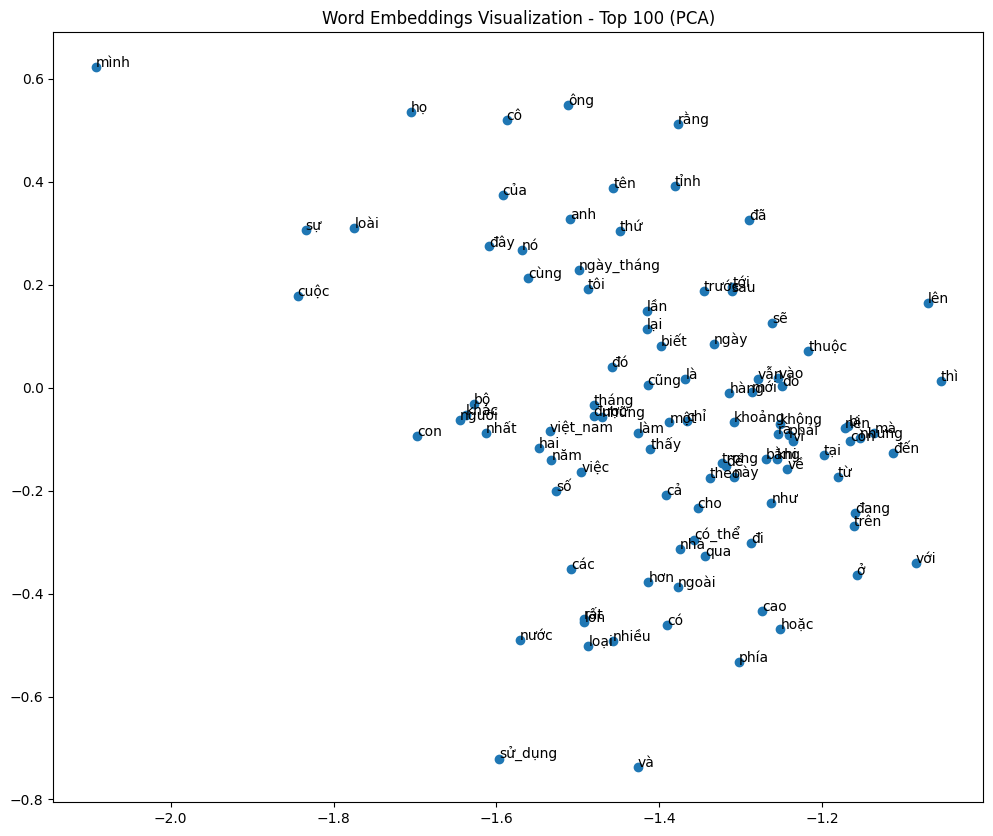

In [34]:
embeddings = glove_50.wi.weight.data
embeds_np = embeddings.cpu().numpy()
plot_embeddings(embeds_np)

visualize 100 frequent words by glove with embeddings = 100

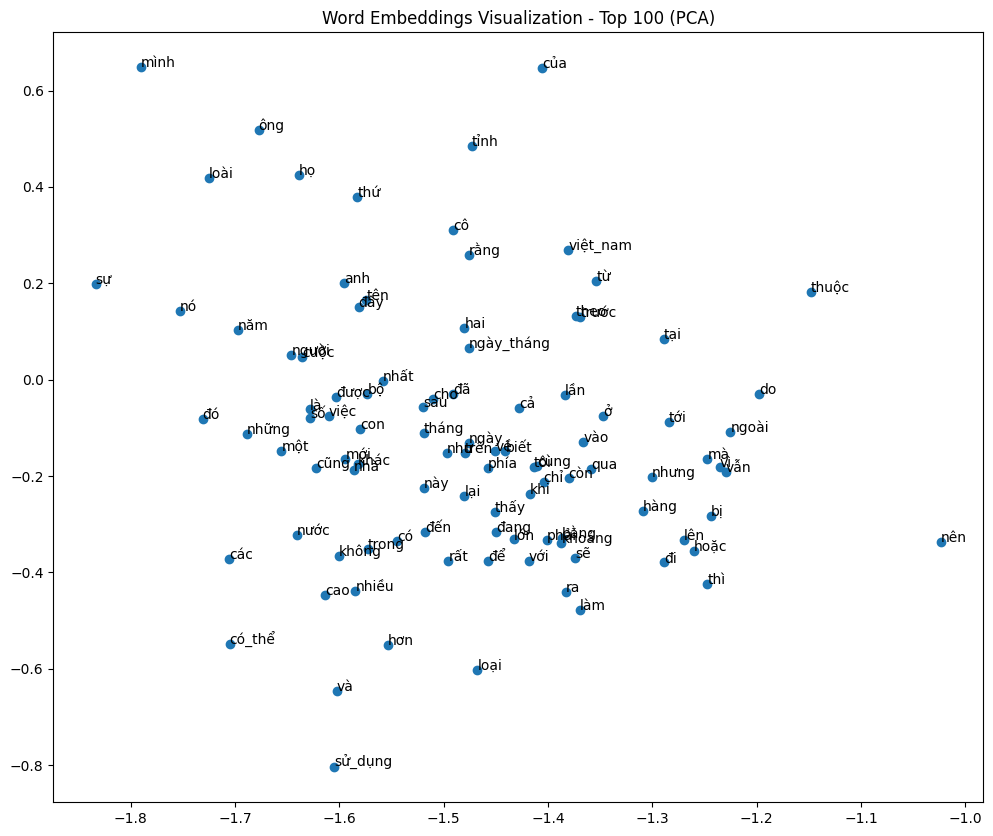

In [37]:
embeddings = glove_100.wi.weight.data
embeds_np = embeddings.cpu().numpy()
plot_embeddings(embeds_np)

Do similar words form clusters?\
Yes, but they might be weak in a 2D PCA. In the full 50D or 100D space, similar words cluster together beautifully. However, PCA is a linear projection that loses a massive amount of information when crushing 100 dimensions down to just 2. You will likely see "mini-clusters" of words with similar grammatical roles (e.g., grouping pronouns like "he/she/it" or verbs like "is/was/are") rather than deep, complex meanings.

Are different topics well separated?\
Usually no, especially when looking at the top 100 frequent words. The most frequent words in almost any dataset are "stop words" (e.g., the, and, of, to, in). Because these words act as the "glue" of the language, they don't belong to any specific topic and usually form a massive, overlapping blob in the center of the graph.

## Part 8: Comparison

| Metric | GloVe (Global Vectors) | Skip-gram (Word2Vec) |
| :--- | :--- | :--- |
| **Core Mechanism** | Co-occurrence Matrix Factorization | Neural Network Prediction |
| **Speed** | Faster training (dependent on vocabulary size) | Slower training (dependent on corpus size) |
| **Quality** | Excels at global semantic relationships | Excels at local syntactic relationships |
| **Stability** | Highly stable and consistent | Lower stability (stochastic variations) |